# 230. Is hydrophobic/polar pattern conserved between remote homologs, and can an exact k-mer see it?

No kmerseek in this notebook. The question is about the biology the HP alphabets are built
on, and about the arithmetic of exact matching, so it is answered from alignments alone.

Two datasets, two questions:

* **Pfam-A seed 38.2** (curated sequence alignments, 163,448 sampled pairs from 29,151
  families, up to 6 pairs per family). Within a family whose members are already known to be
  homologous, how much of the hydrophobic/polar (HP) pattern survives as identity drops?
* **SCOPe 2.08, 40% set** (USalign structural alignments of 38,267 sampled domain pairs).
  Across families of one superfamily, where sequence alignment is unreliable and the
  correspondence comes from structure, does the same hold? And how much HP agreement do
  structurally aligned *non*-homologs (different fold, same class) show, which is the part
  of the signal that is packing, not ancestry?

For every pair and every alphabet the measure is agreement between aligned residues,
corrected for chance with Cohen's kappa: `(agree - expected) / (1 - expected)`, where
`expected = sum_c f_q(c) f_t(c)` is what a composition-preserving shuffle of one partner
gives. Kappa puts a 2-letter alphabet (chance agreement about 0.5) and the 20-letter one
(chance about 0.06) on one scale. Then the longest exact run: the longest stretch of aligned
columns with no gap and the same class on both sides, which is the longest k-mer the pair
shares in that alphabet, and the only thing an exact-match k-mer index can see.

Inputs come from `scripts/pfam_seed_pair_alignments.py` and
`scripts/scope_pair_structural_alignments.py`; the per-pair table is computed by
`notebooks/hp_conservation_utils.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

FIG = Path("../figures")
PFAM = "/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet"
SCOPE = "/Users/olga/data/scope/230_scope40_pair_class_agreement.parquet"
MIN_COLS = 50  # aligned columns; shorter alignments give noisy kappa and no long runs
MIN_TM = 0.5  # SCOPe pairs only: the structural alignment must be a real superposition

pfam = hc.add_identity_bin(pl.read_parquet(PFAM)).filter(pl.col("n_cols") >= MIN_COLS)
scope = hc.add_identity_bin(pl.read_parquet(SCOPE)).with_columns(
    pl.max_horizontal("tm_q", "tm_t").alias("tm_max")
)
scope_all = scope.filter(pl.col("n_cols") >= MIN_COLS)
scope = scope_all.filter(pl.col("tm_max") >= MIN_TM)

CAT_ORDER = [
    "same_family",
    "same_superfamily_diff_family",
    "same_fold_diff_superfamily",
    "diff_fold_same_class",
]
CAT_LABEL = {
    "same_family": "same family",
    "same_superfamily_diff_family": "same superfamily,\ndifferent family",
    "same_fold_diff_superfamily": "same fold,\ndifferent superfamily",
    "diff_fold_same_class": "different fold\n(same class)",
}
ALPHA_COLOR = {
    "protein20": "#444444",
    "uniprot18": "#777777",
    "sdm12": "#8c6d31",
    "gbmr7": "#bd9e39",
    "dayhoff6": "#e7ba52",
    "wwmj5": "#6b6ecf",
    "polarity4": "#3182bd",
    "gbmr4": "#6baed6",
    "hp_lehninger_hpc3": "#e6550d",
    "hp_lehninger2": "#d62728",
    "hp_thomas_dill2": "#a50f15",
    "hp_kyte_doolittle2": "#fb6a4a",
    "hp_thomas_dill_no_c2": "#fc9272",
    "hp_lehninger_c_nonpolar2": "#fcbba1",
    "hp_pbotc_1st_ed2": "#7f0000",
}


def n_pairs(df):
    return df.select("query", "target").unique().height


print(
    f"Pfam seed pairs kept (>= {MIN_COLS} aligned columns): {n_pairs(pfam):,} of {n_pairs(pl.read_parquet(PFAM)):,}"
)
print(
    f"SCOPe pairs kept (>= {MIN_COLS} columns, TM-score >= {MIN_TM}): {n_pairs(scope):,} of {n_pairs(scope_all):,}"
)
print(
    scope.select("query", "target", "category")
    .unique()
    .group_by("category")
    .len()
    .sort("category")
)

Pfam seed pairs kept (>= 50 aligned columns): 148,482 of 163,448
SCOPe pairs kept (>= 50 columns, TM-score >= 0.5): 24,505 of 33,635
shape: (4, 2)
┌──────────────────────────────┬───────┐
│ category                     ┆ len   │
│ ---                          ┆ ---   │
│ str                          ┆ u32   │
╞══════════════════════════════╪═══════╡
│ diff_fold_same_class         ┆ 186   │
│ same_family                  ┆ 11117 │
│ same_fold_diff_superfamily   ┆ 1204  │
│ same_superfamily_diff_family ┆ 11998 │
└──────────────────────────────┴───────┘


## 1. What identities the two datasets cover

Pfam seed pairs sit mostly between 20% and 60% identity. The SCOPe pairs are far more
divergent: within a superfamily but across families the median identity over structurally
aligned columns is 13%, and the different-fold control sits at 7%, which is what two
unrelated sequences look like when a structural superposition forces them into columns.

shape: (5, 7)
┌───────────┬─────────────────────────────────┬───────┬────────┬────────┬────────┬───────┐
│ dataset   ┆ category                        ┆ <20%  ┆ 20-30% ┆ 30-40% ┆ 40-60% ┆ >=60% │
│ ---       ┆ ---                             ┆ ---   ┆ ---    ┆ ---    ┆ ---    ┆ ---   │
│ str       ┆ str                             ┆ u32   ┆ u32    ┆ u32    ┆ u32    ┆ u32   │
╞═══════════╪═════════════════════════════════╪═══════╪════════╪════════╪════════╪═══════╡
│ Pfam seed ┆ same family                     ┆ 16407 ┆ 37085  ┆ 34512  ┆ 41508  ┆ 18970 │
│ SCOPe     ┆ different fold (same class)     ┆ 186   ┆ 0      ┆ 0      ┆ 0      ┆ 0     │
│ SCOPe     ┆ same family                     ┆ 5503  ┆ 3594   ┆ 1819   ┆ 196    ┆ 5     │
│ SCOPe     ┆ same fold, different superfami… ┆ 1192  ┆ 12     ┆ 0      ┆ 0      ┆ 0     │
│ SCOPe     ┆ same superfamily, different fa… ┆ 8815  ┆ 2118   ┆ 944    ┆ 121    ┆ 0     │
└───────────┴─────────────────────────────────┴───────┴────────┴────────┴───

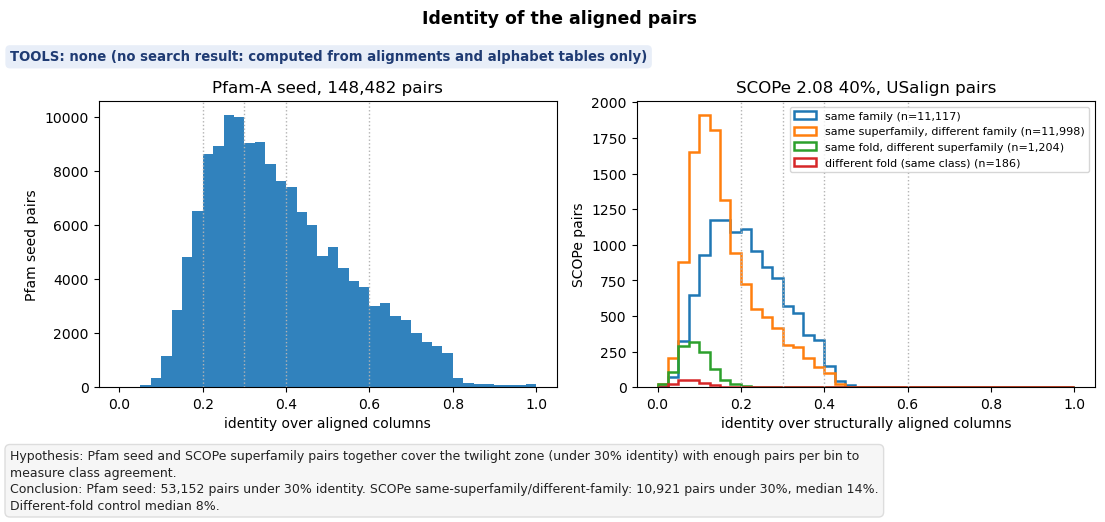

In [2]:
pf1 = pfam.filter(pl.col("alphabet") == "protein20")
sc1 = scope.filter(pl.col("alphabet") == "protein20")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.hist(pf1["seqid_ali"], bins=np.linspace(0, 1, 41), color="#3182bd")
ax.set_xlabel("identity over aligned columns")
ax.set_ylabel("Pfam seed pairs")
ax.set_title(f"Pfam-A seed, {pf1.height:,} pairs")
ax = axes[1]
for cat in CAT_ORDER:
    x = sc1.filter(pl.col("category") == cat)["seqid_ali"]
    ax.hist(
        x,
        bins=np.linspace(0, 1, 41),
        histtype="step",
        lw=1.8,
        label=f"{CAT_LABEL[cat].replace(chr(10), ' ')} (n={x.len():,})",
    )
ax.set_xlabel("identity over structurally aligned columns")
ax.set_ylabel("SCOPe pairs")
ax.set_title("SCOPe 2.08 40%, USalign pairs")
ax.legend(fontsize=8)
for ax in axes:
    for b in hc.IDENTITY_BINS[1:-1]:
        ax.axvline(b, color="0.7", ls=":", lw=1)

tab = pl.concat(
    [
        pf1.group_by(
            pl.lit("Pfam seed").alias("dataset"),
            pl.lit("same family").alias("category"),
            "identity_bin",
        )
        .len()
        .sort("identity_bin"),
        sc1.with_columns(pl.col("category").replace(CAT_LABEL).str.replace("\n", " "))
        .group_by(pl.lit("SCOPe").alias("dataset"), "category", "identity_bin")
        .len()
        .sort("category", "identity_bin"),
    ],
    how="diagonal_relaxed",
)
print(
    tab.pivot(on="identity_bin", index=["dataset", "category"], values="len").fill_null(
        0
    )
)
hc.finish_figure(
    fig,
    FIG / "230_identity_distributions.png",
    tools=hc.NO_TOOL,
    hypothesis="Pfam seed and SCOPe superfamily pairs together cover the twilight zone (under 30% identity) with enough pairs per bin to measure class agreement.",
    conclusion=(
        f"Pfam seed: {pf1.filter(pl.col('seqid_ali') < 0.3).height:,} pairs under 30% identity. SCOPe same-superfamily/different-family: "
        f"{sc1.filter((pl.col('category') == 'same_superfamily_diff_family') & (pl.col('seqid_ali') < 0.3)).height:,} pairs under 30%, median "
        f"{100 * sc1.filter(pl.col('category') == 'same_superfamily_diff_family')['seqid_ali'].median():.0f}%. Different-fold control median "
        f"{100 * sc1.filter(pl.col('category') == 'diff_fold_same_class')['seqid_ali'].median():.0f}%."
    ),
    title="Identity of the aligned pairs",
)

## 2. Class agreement above chance, by identity

Kappa per pair, averaged within identity bin, with a bootstrap 95% CI on the mean. Zero is
the composition-shuffle null. The 20-letter alphabet's kappa is the residue identity
itself, chance-corrected, so it is the reference the reduced alphabets have to beat.

shape: (17, 8)
┌──────────────────────────────┬──────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┐
│ category                     ┆ identity_bin ┆ protein20            ┆ dayhoff6             ┆ gbmr4                ┆ polarity4            ┆ hp_thomas_dill2      ┆ hp_pbotc_1st_ed2     │
│ ---                          ┆ ---          ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                  │
│ str                          ┆ str          ┆ str                  ┆ str                  ┆ str                  ┆ str                  ┆ str                  ┆ str                  │
╞══════════════════════════════╪══════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ Pfam                         ┆ 20-30%       ┆ 0.199 [

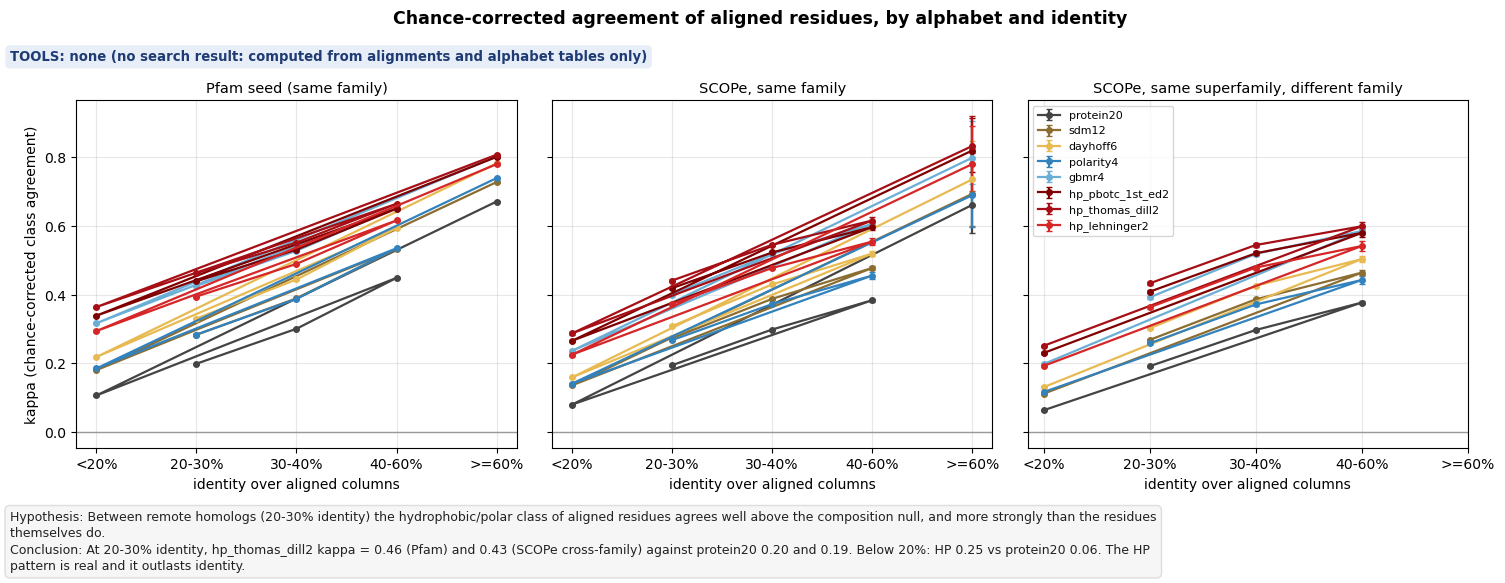

In [3]:
def kappa_summary(df, extra):
    return hc.summarise(
        df.filter(pl.col("alphabet").is_in(hc.PANEL)),
        extra + ["identity_bin", "alphabet"],
        "kappa",
    )


kp = kappa_summary(pfam, [])
ks = kappa_summary(scope, ["category"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
panels = [
    (axes[0], kp, "Pfam seed (same family)"),
    (axes[1], ks.filter(pl.col("category") == "same_family"), "SCOPe, same family"),
    (
        axes[2],
        ks.filter(pl.col("category") == "same_superfamily_diff_family"),
        "SCOPe, same superfamily, different family",
    ),
]
x = np.arange(len(hc.IDENTITY_LABELS))
for ax, d, title in panels:
    for a in hc.PANEL:
        s = d.filter(pl.col("alphabet") == a).sort("identity_bin")
        xi = np.array([hc.IDENTITY_LABELS.index(b) for b in s["identity_bin"]])
        ax.errorbar(
            xi,
            s["kappa_mean"],
            yerr=[s["kappa_mean"] - s["kappa_lo"], s["kappa_hi"] - s["kappa_mean"]],
            marker="o",
            ms=4,
            lw=1.6,
            capsize=2,
            color=ALPHA_COLOR[a],
            label=a,
        )
    ax.set_xticks(x, hc.IDENTITY_LABELS)
    ax.set_xlabel("identity over aligned columns")
    ax.set_title(title, fontsize=10.5)
    ax.axhline(0, color="0.6", lw=1)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("kappa (chance-corrected class agreement)")
axes[2].legend(fontsize=8, loc="upper left")

show = pl.concat(
    [kp.with_columns(pl.lit("Pfam").alias("category")), ks], how="diagonal_relaxed"
).filter(
    pl.col("alphabet").is_in(
        [
            "protein20",
            "dayhoff6",
            "polarity4",
            "gbmr4",
            "hp_thomas_dill2",
            "hp_pbotc_1st_ed2",
        ]
    )
)
print(
    show.with_columns(
        pl.format(
            "{} [{}, {}]",
            pl.col("kappa_mean").round(3),
            pl.col("kappa_lo").round(3),
            pl.col("kappa_hi").round(3),
        ).alias("kappa")
    )
    .pivot(on="alphabet", index=["category", "identity_bin"], values="kappa")
    .sort("category", "identity_bin")
)


def kap(d, a, b, cat=None):
    s = d.filter(
        (pl.col("alphabet") == a)
        & (pl.col("identity_bin") == b)
        & ((pl.col("category") == cat) if cat else True)
    )
    return s["kappa_mean"][0]


hc.finish_figure(
    fig,
    FIG / "230_kappa_by_identity.png",
    tools=hc.NO_TOOL,
    hypothesis="Between remote homologs (20-30% identity) the hydrophobic/polar class of aligned residues agrees well above the composition null, and more strongly than the residues themselves do.",
    conclusion=(
        f"At 20-30% identity, hp_thomas_dill2 kappa = {kap(kp, 'hp_thomas_dill2', '20-30%'):.2f} (Pfam) and "
        f"{kap(ks, 'hp_thomas_dill2', '20-30%', 'same_superfamily_diff_family'):.2f} (SCOPe cross-family) against protein20 "
        f"{kap(kp, 'protein20', '20-30%'):.2f} and {kap(ks, 'protein20', '20-30%', 'same_superfamily_diff_family'):.2f}. "
        f"Below 20%: HP {kap(ks, 'hp_thomas_dill2', '<20%', 'same_superfamily_diff_family'):.2f} vs protein20 {kap(ks, 'protein20', '<20%', 'same_superfamily_diff_family'):.2f}. The HP pattern is real and it outlasts identity."
    ),
    title="Chance-corrected agreement of aligned residues, by alphabet and identity",
)

## 3. How much of that is homology, and how much is packing?

Two structurally aligned residues can share an HP class because they descend from one
ancestral residue, or because both sit buried in the same place of a similar fold. The
different-fold control separates the two: those pairs have no common ancestor and no common
fold, only a superposition. Same-fold/different-superfamily pairs are the ambiguous middle
(SCOP does not assert homology across superfamilies). This panel restricts to pairs under 20%
identity so the categories are compared at the same identity.

shape: (32, 6)
┌──────────────────────────────┬──────────────────┬──────┬────────────┬──────────┬──────────┐
│ category                     ┆ alphabet         ┆ n    ┆ kappa_mean ┆ kappa_lo ┆ kappa_hi │
│ ---                          ┆ ---              ┆ ---  ┆ ---        ┆ ---      ┆ ---      │
│ enum                         ┆ str              ┆ i64  ┆ f64        ┆ f64      ┆ f64      │
╞══════════════════════════════╪══════════════════╪══════╪════════════╪══════════╪══════════╡
│ same_family                  ┆ dayhoff6         ┆ 5503 ┆ 0.159      ┆ 0.157    ┆ 0.161    │
│ same_family                  ┆ gbmr4            ┆ 5503 ┆ 0.236      ┆ 0.234    ┆ 0.239    │
│ same_family                  ┆ hp_lehninger2    ┆ 5503 ┆ 0.225      ┆ 0.222    ┆ 0.228    │
│ same_family                  ┆ hp_pbotc_1st_ed2 ┆ 5503 ┆ 0.266      ┆ 0.262    ┆ 0.268    │
│ same_family                  ┆ hp_thomas_dill2  ┆ 5503 ┆ 0.287      ┆ 0.284    ┆ 0.29     │
│ same_family                  ┆ polarity4   

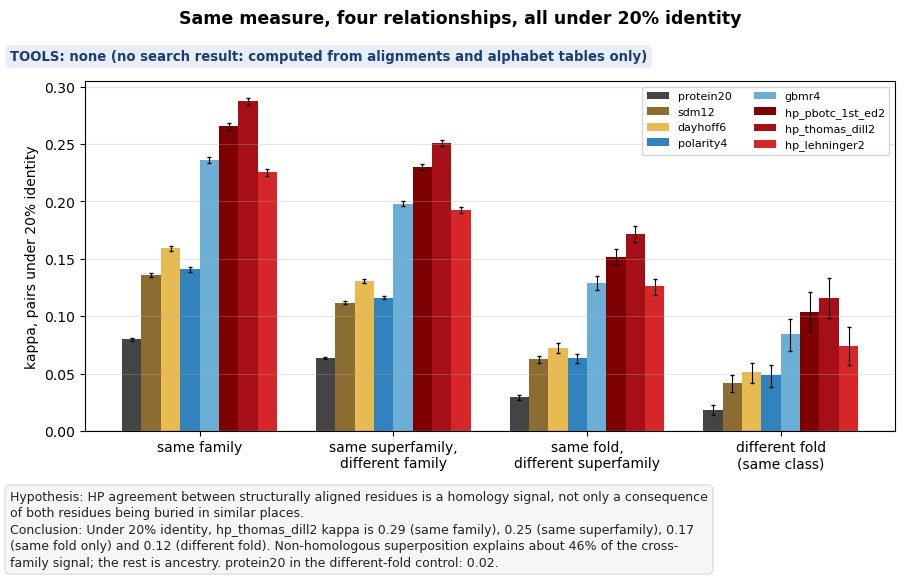

In [4]:
low = scope.filter(
    (pl.col("identity_bin") == "<20%") & pl.col("alphabet").is_in(hc.PANEL)
)
kc = hc.summarise(low, ["category", "alphabet"], "kappa")

fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.8 / len(hc.PANEL)
for i, a in enumerate(hc.PANEL):
    s = kc.filter(pl.col("alphabet") == a)
    s = s.with_columns(pl.col("category").cast(pl.Enum(CAT_ORDER))).sort("category")
    xi = np.arange(len(CAT_ORDER)) + (i - len(hc.PANEL) / 2 + 0.5) * w
    ax.bar(
        xi,
        s["kappa_mean"],
        w,
        yerr=[s["kappa_mean"] - s["kappa_lo"], s["kappa_hi"] - s["kappa_mean"]],
        color=ALPHA_COLOR[a],
        label=a,
        capsize=1.5,
        error_kw=dict(lw=0.8),
    )
ax.set_xticks(np.arange(len(CAT_ORDER)), [CAT_LABEL[c] for c in CAT_ORDER])
ax.set_ylabel("kappa, pairs under 20% identity")
ax.axhline(0, color="0.6", lw=1)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)

print(
    kc.with_columns(pl.col("category").cast(pl.Enum(CAT_ORDER)))
    .sort("category", "alphabet")
    .select(
        "category",
        "alphabet",
        "n",
        pl.col("kappa_mean").round(3),
        pl.col("kappa_lo").round(3),
        pl.col("kappa_hi").round(3),
    )
)


def kk(cat, a="hp_thomas_dill2"):
    return kc.filter((pl.col("category") == cat) & (pl.col("alphabet") == a))[
        "kappa_mean"
    ][0]


share = kk("diff_fold_same_class") / kk("same_superfamily_diff_family")
hc.finish_figure(
    fig,
    FIG / "230_kappa_homology_vs_packing.png",
    tools=hc.NO_TOOL,
    hypothesis="HP agreement between structurally aligned residues is a homology signal, not only a consequence of both residues being buried in similar places.",
    conclusion=(
        f"Under 20% identity, hp_thomas_dill2 kappa is {kk('same_family'):.2f} (same family), {kk('same_superfamily_diff_family'):.2f} (same superfamily), "
        f"{kk('same_fold_diff_superfamily'):.2f} (same fold only) and {kk('diff_fold_same_class'):.2f} (different fold). "
        f"Non-homologous superposition explains about {100 * share:.0f}% of the cross-family signal; the rest is ancestry. "
        f"protein20 in the different-fold control: {kk('diff_fold_same_class', 'protein20'):.2f}."
    ),
    title="Same measure, four relationships, all under 20% identity",
)

## 4. The longest exact run: what an exact k-mer index can see

Kappa is about single columns. An exact-match index needs k consecutive columns with no gap
and no class change on either side. The longest such run per pair is the longest k-mer the
two share; if it is shorter than the index's k, the pair is invisible to that index no matter
how strong the per-column signal is.

The null here is the same pair with the target's residues shuffled (composition kept, gaps
kept), which shows how long a run two unrelated sequences of this composition produce by
chance in a 2-letter alphabet.

shape: (36, 6)
┌────────────────────┬──────────────┬─────────────────┬───────┬──────────────────┬───────────────────────┐
│ dataset            ┆ identity_bin ┆ alphabet        ┆ n     ┆ longest_run_mean ┆ longest_run_null_mean │
│ ---                ┆ ---          ┆ ---             ┆ ---   ┆ ---              ┆ ---                   │
│ str                ┆ str          ┆ str             ┆ i64   ┆ f64              ┆ f64                   │
╞════════════════════╪══════════════╪═════════════════╪═══════╪══════════════════╪═══════════════════════╡
│ Pfam               ┆ 20-30%       ┆ dayhoff6        ┆ 37085 ┆ 7.0              ┆ 3.0                   │
│ Pfam               ┆ 20-30%       ┆ gbmr4           ┆ 37085 ┆ 11.0             ┆ 5.1                   │
│ Pfam               ┆ 20-30%       ┆ hp_thomas_dill2 ┆ 37085 ┆ 13.0             ┆ 6.3                   │
│ Pfam               ┆ 20-30%       ┆ protein20       ┆ 37085 ┆ 3.8              ┆ 1.5                   │
│ Pfam               ┆

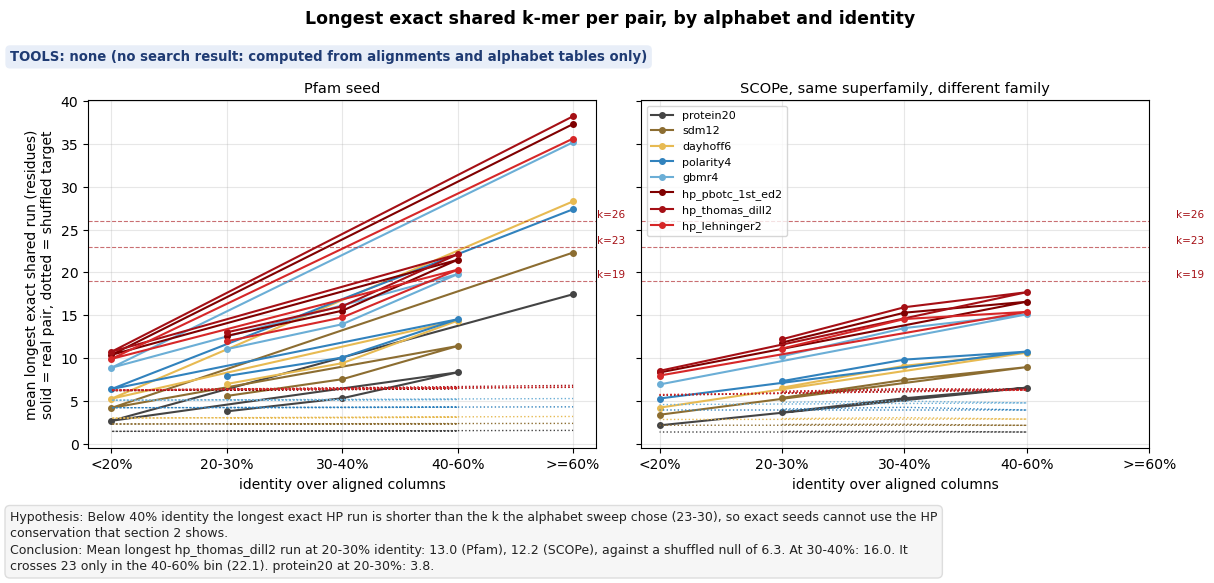

In [5]:
runs_p = hc.summarise(
    pfam.filter(pl.col("alphabet").is_in(hc.PANEL)),
    ["identity_bin", "alphabet"],
    "longest_run",
)
null_p = hc.summarise(
    pfam.filter(pl.col("alphabet").is_in(hc.PANEL)),
    ["identity_bin", "alphabet"],
    "longest_run_null",
)
sf = scope.filter(
    (pl.col("category") == "same_superfamily_diff_family")
    & pl.col("alphabet").is_in(hc.PANEL)
)
runs_s = hc.summarise(sf, ["identity_bin", "alphabet"], "longest_run")
null_s = hc.summarise(sf, ["identity_bin", "alphabet"], "longest_run_null")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, r, nl, title in [
    (axes[0], runs_p, null_p, "Pfam seed"),
    (axes[1], runs_s, null_s, "SCOPe, same superfamily, different family"),
]:
    for a in hc.PANEL:
        s = r.filter(pl.col("alphabet") == a).sort("identity_bin")
        xi = [hc.IDENTITY_LABELS.index(b) for b in s["identity_bin"]]
        ax.plot(
            xi, s["longest_run_mean"], marker="o", ms=4, color=ALPHA_COLOR[a], label=a
        )
        s0 = nl.filter(pl.col("alphabet") == a).sort("identity_bin")
        ax.plot(
            [hc.IDENTITY_LABELS.index(b) for b in s0["identity_bin"]],
            s0["longest_run_null_mean"],
            ls=":",
            color=ALPHA_COLOR[a],
            lw=1,
        )
    for k, lab in [(19, "k=19"), (23, "k=23"), (26, "k=26")]:
        ax.axhline(k, color="#a50f15", lw=0.8, ls="--", alpha=0.6)
        ax.text(
            len(hc.IDENTITY_LABELS) - 0.55,
            k + 0.4,
            lab,
            fontsize=7.5,
            color="#a50f15",
            ha="right",
        )
    ax.set_xticks(range(len(hc.IDENTITY_LABELS)), hc.IDENTITY_LABELS)
    ax.set_xlabel("identity over aligned columns")
    ax.set_title(title, fontsize=10.5)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(
    "mean longest exact shared run (residues)\nsolid = real pair, dotted = shuffled target"
)
axes[1].legend(fontsize=8, loc="upper left")

both = pl.concat(
    [
        runs_p.join(null_p, on=["identity_bin", "alphabet", "n"]).with_columns(
            pl.lit("Pfam").alias("dataset")
        ),
        runs_s.join(null_s, on=["identity_bin", "alphabet", "n"]).with_columns(
            pl.lit("SCOPe cross-family").alias("dataset")
        ),
    ],
    how="diagonal_relaxed",
).filter(
    pl.col("alphabet").is_in(["protein20", "dayhoff6", "gbmr4", "hp_thomas_dill2"])
)
print(
    both.select(
        "dataset",
        "identity_bin",
        "alphabet",
        "n",
        pl.col("longest_run_mean").round(1),
        pl.col("longest_run_null_mean").round(1),
    ).sort("dataset", "identity_bin", "alphabet")
)


def rr(r, a, b):
    return r.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b))[
        "longest_run_mean"
    ][0]


hc.finish_figure(
    fig,
    FIG / "230_longest_run_by_identity.png",
    tools=hc.NO_TOOL,
    hypothesis="Below 40% identity the longest exact HP run is shorter than the k the alphabet sweep chose (23-30), so exact seeds cannot use the HP conservation that section 2 shows.",
    conclusion=(
        f"Mean longest hp_thomas_dill2 run at 20-30% identity: {rr(runs_p, 'hp_thomas_dill2', '20-30%'):.1f} (Pfam), {rr(runs_s, 'hp_thomas_dill2', '20-30%'):.1f} (SCOPe), "
        f"against a shuffled null of {null_p.filter((pl.col('alphabet') == 'hp_thomas_dill2') & (pl.col('identity_bin') == '20-30%'))['longest_run_null_mean'][0]:.1f}. "
        f"At 30-40%: {rr(runs_p, 'hp_thomas_dill2', '30-40%'):.1f}. It crosses 23 only in the 40-60% bin ({rr(runs_p, 'hp_thomas_dill2', '40-60%'):.1f}). "
        f"protein20 at 20-30%: {rr(runs_p, 'protein20', '20-30%'):.1f}."
    ),
    title="Longest exact shared k-mer per pair, by alphabet and identity",
)

## 5. The fraction of pairs an exact index of size k can reach

Same quantity as a survival curve: for each k, the fraction of pairs whose longest exact run
is at least k. This is the ceiling on recall for an exact-match index in that alphabet at
that k, before any scoring, thresholding or database noise. The three marked k values are
the ones the QfO Pfam sweep chose for the 2-letter arms (19 for hp_pbotc_1st_ed, 23 and 26 for
hp_thomas_dill).

shape: (45, 11)
┌────────────────────┬──────────────┬──────────────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ dataset            ┆ identity_bin ┆ alphabet         ┆ 5     ┆ 7     ┆ 10    ┆ 15    ┆ 19    ┆ 23    ┆ 26    ┆ 30    │
│ ---                ┆ ---          ┆ ---              ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str                ┆ enum         ┆ str              ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞════════════════════╪══════════════╪══════════════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ Pfam               ┆ <20%         ┆ dayhoff6         ┆ 0.611 ┆ 0.207 ┆ 0.032 ┆ 0.001 ┆ 0.0   ┆ 0.0   ┆ 0.0   ┆ 0.0   │
│ Pfam               ┆ <20%         ┆ gbmr4            ┆ 0.974 ┆ 0.784 ┆ 0.345 ┆ 0.052 ┆ 0.01  ┆ 0.002 ┆ 0.001 ┆ 0.0   │
│ Pfam               ┆ <20%         ┆ hp_pbotc_1st_ed2 ┆ 0.992 ┆ 0.906 ┆ 0.538 ┆ 0.114 ┆ 0.027 ┆ 0.006 ┆ 0.002 ┆ 0.001 │
│ Pfam          

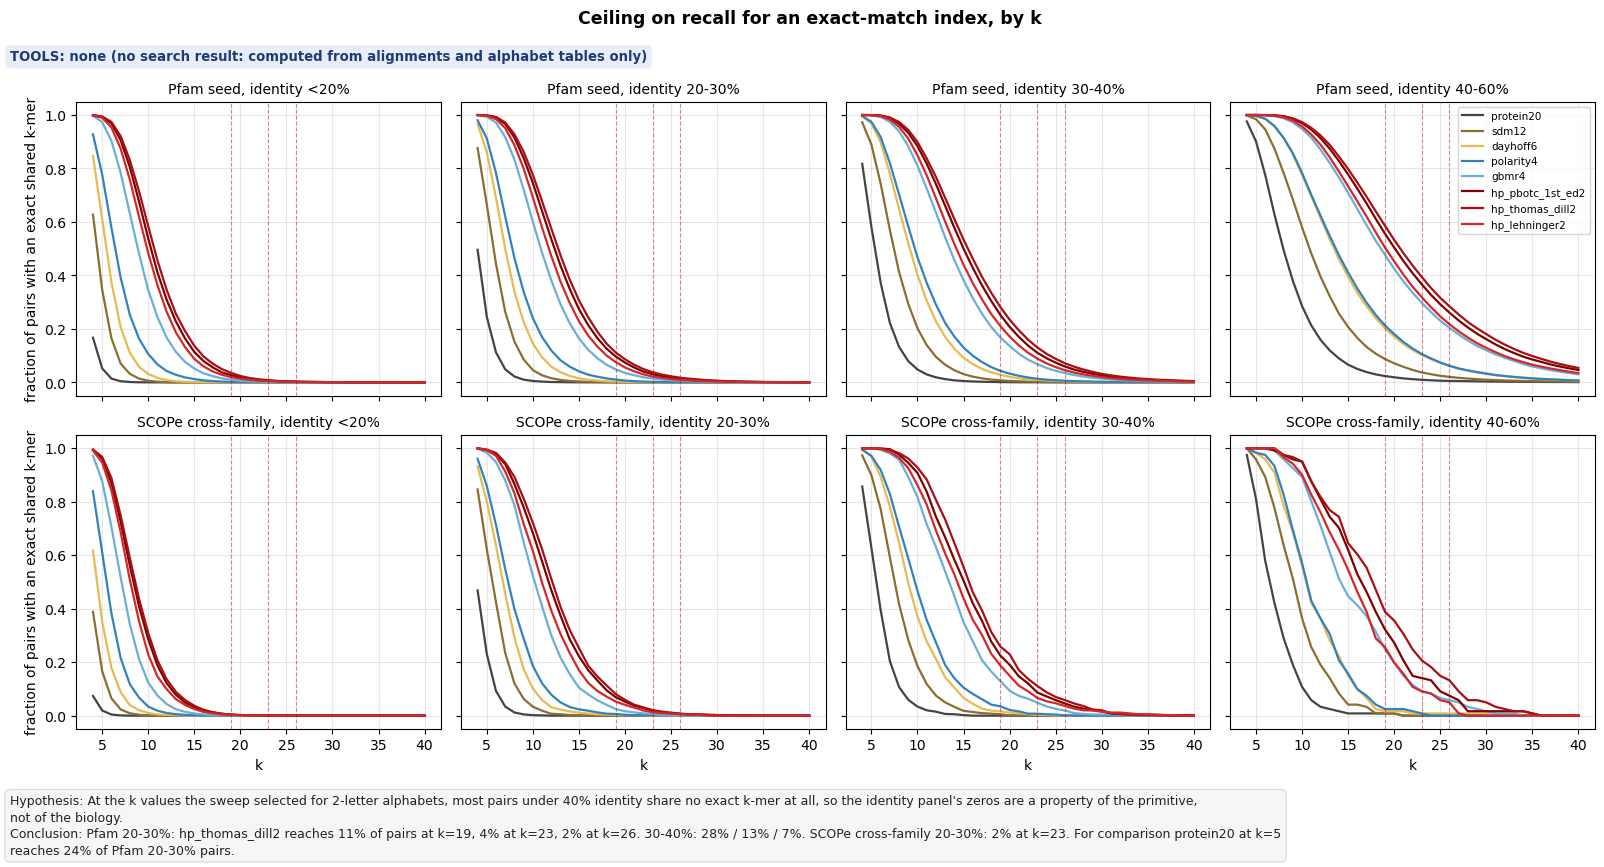

In [6]:
KS = list(range(4, 41))
fr_p = hc.frac_run_at_least(
    pfam.filter(pl.col("alphabet").is_in(hc.PANEL)), ["identity_bin", "alphabet"], KS
)
fr_s = hc.frac_run_at_least(sf, ["identity_bin", "alphabet"], KS)

bins_shown = ["<20%", "20-30%", "30-40%", "40-60%"]
fig, axes = plt.subplots(
    2, len(bins_shown), figsize=(16, 7.2), sharex=True, sharey=True
)
for row, (fr, title) in enumerate([(fr_p, "Pfam seed"), (fr_s, "SCOPe cross-family")]):
    for j, b in enumerate(bins_shown):
        ax = axes[row, j]
        for a in hc.PANEL:
            s = fr.filter(
                (pl.col("alphabet") == a) & (pl.col("identity_bin") == b)
            ).sort("k")
            if s.height:
                ax.plot(s["k"], s["frac"], color=ALPHA_COLOR[a], label=a, lw=1.6)
        for k in (19, 23, 26):
            ax.axvline(k, color="#a50f15", lw=0.8, ls="--", alpha=0.5)
        ax.set_title(f"{title}, identity {b}", fontsize=10)
        ax.grid(alpha=0.3)
        if row == 1:
            ax.set_xlabel("k")
        if j == 0:
            ax.set_ylabel("fraction of pairs with an exact shared k-mer")
axes[0, -1].legend(fontsize=7.5)

pick = pl.concat(
    [
        fr_p.with_columns(pl.lit("Pfam").alias("dataset")),
        fr_s.with_columns(pl.lit("SCOPe cross-family").alias("dataset")),
    ],
    how="diagonal_relaxed",
).filter(
    pl.col("k").is_in([5, 7, 10, 15, 19, 23, 26, 30])
    & pl.col("alphabet").is_in(
        ["protein20", "dayhoff6", "gbmr4", "hp_thomas_dill2", "hp_pbotc_1st_ed2"]
    )
)
print(
    pick.with_columns(pl.col("frac").round(3))
    .pivot(on="k", index=["dataset", "identity_bin", "alphabet"], values="frac")
    .sort("dataset", "identity_bin", "alphabet")
)


def ff(fr, a, b, k):
    return fr.filter(
        (pl.col("alphabet") == a) & (pl.col("identity_bin") == b) & (pl.col("k") == k)
    )["frac"][0]


hc.finish_figure(
    fig,
    FIG / "230_reachable_fraction_vs_k.png",
    tools=hc.NO_TOOL,
    hypothesis="At the k values the sweep selected for 2-letter alphabets, most pairs under 40% identity share no exact k-mer at all, so the identity panel's zeros are a property of the primitive, not of the biology.",
    conclusion=(
        f"Pfam 20-30%: hp_thomas_dill2 reaches {100 * ff(fr_p, 'hp_thomas_dill2', '20-30%', 19):.0f}% of pairs at k=19, {100 * ff(fr_p, 'hp_thomas_dill2', '20-30%', 23):.0f}% at k=23, {100 * ff(fr_p, 'hp_thomas_dill2', '20-30%', 26):.0f}% at k=26. "
        f"30-40%: {100 * ff(fr_p, 'hp_thomas_dill2', '30-40%', 19):.0f}% / {100 * ff(fr_p, 'hp_thomas_dill2', '30-40%', 23):.0f}% / {100 * ff(fr_p, 'hp_thomas_dill2', '30-40%', 26):.0f}%. "
        f"SCOPe cross-family 20-30%: {100 * ff(fr_s, 'hp_thomas_dill2', '20-30%', 23):.0f}% at k=23. For comparison protein20 at k=5 reaches {100 * ff(fr_p, 'protein20', '20-30%', 5):.0f}% of Pfam 20-30% pairs."
    ),
    title="Ceiling on recall for an exact-match index, by k",
)

## 6. Bits, not letters: the same curves on a shared information axis

A k-mer in an s-letter alphabet carries k·log2(s) bits. The QfO report's winner analysis said
the arms that win share a bits-per-k-mer band (median 28, IQR 23-32) rather than an
alphabet. If that band is the real constraint, then at matched bits every alphabet should
reach a similar fraction of pairs, and the question "which alphabet" becomes "how many bits
can you afford". This replots section 5 with the x-axis in bits.

Fraction of Pfam pairs reachable at about 26 bits per k-mer:
shape: (8, 7)
┌──────────────────┬─────┬──────┬───────┬────────┬────────┬────────┐
│ alphabet         ┆ k   ┆ bits ┆ <20%  ┆ 20-30% ┆ 30-40% ┆ 40-60% │
│ ---              ┆ --- ┆ ---  ┆ ---   ┆ ---    ┆ ---    ┆ ---    │
│ str              ┆ i64 ┆ f64  ┆ f64   ┆ f64    ┆ f64    ┆ f64    │
╞══════════════════╪═════╪══════╪═══════╪════════╪════════╪════════╡
│ protein20        ┆ 6   ┆ 25.9 ┆ 0.014 ┆ 0.112  ┆ 0.373  ┆ 0.776  │
│ sdm12            ┆ 7   ┆ 25.1 ┆ 0.07  ┆ 0.264  ┆ 0.571  ┆ 0.874  │
│ dayhoff6         ┆ 10  ┆ 25.8 ┆ 0.032 ┆ 0.145  ┆ 0.403  ┆ 0.776  │
│ polarity4        ┆ 13  ┆ 26.0 ┆ 0.028 ┆ 0.083  ┆ 0.223  ┆ 0.548  │
│ gbmr4            ┆ 13  ┆ 26.0 ┆ 0.114 ┆ 0.293  ┆ 0.542  ┆ 0.82   │
│ hp_pbotc_1st_ed2 ┆ 26  ┆ 26.0 ┆ 0.002 ┆ 0.014  ┆ 0.059  ┆ 0.261  │
│ hp_thomas_dill2  ┆ 26  ┆ 26.0 ┆ 0.003 ┆ 0.017  ┆ 0.071  ┆ 0.284  │
│ hp_lehninger2    ┆ 26  ┆ 26.0 ┆ 0.002 ┆ 0.009  ┆ 0.045  ┆ 0.217  │
└──────────────────┴─────┴──

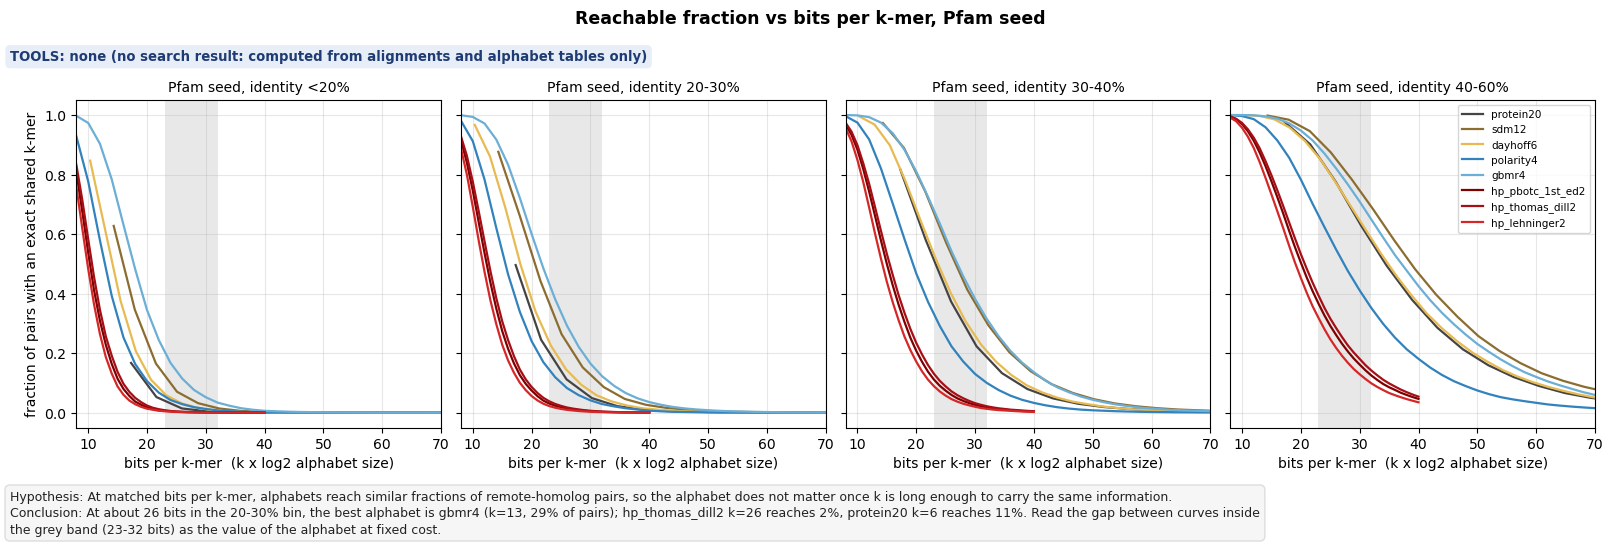

In [7]:
fig, axes = plt.subplots(1, len(bins_shown), figsize=(16, 4.2), sharey=True)
for j, b in enumerate(bins_shown):
    ax = axes[j]
    for a in hc.PANEL:
        s = fr_p.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b)).sort(
            "k"
        )
        ax.plot(s["k"] * hc.BITS[a], s["frac"], color=ALPHA_COLOR[a], label=a, lw=1.6)
    ax.axvspan(23, 32, color="0.85", alpha=0.6, lw=0)
    ax.set_xlim(8, 70)
    ax.set_title(f"Pfam seed, identity {b}", fontsize=10)
    ax.set_xlabel("bits per k-mer  (k x log2 alphabet size)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("fraction of pairs with an exact shared k-mer")
axes[-1].legend(fontsize=7.5)

# Nearest-k comparison at ~26 bits: protein20 k=6 (25.9 bits), sdm12 k=7 (25.1), dayhoff6 k=10 (25.8),
# gbmr4/polarity4 k=13 (26), hp k=26.
at26 = {
    "protein20": 6,
    "sdm12": 7,
    "dayhoff6": 10,
    "polarity4": 13,
    "gbmr4": 13,
    "hp_pbotc_1st_ed2": 26,
    "hp_thomas_dill2": 26,
    "hp_lehninger2": 26,
}
rows = []
for a, k in at26.items():
    for b in bins_shown:
        rows.append(
            {
                "alphabet": a,
                "k": k,
                "bits": round(k * hc.BITS[a], 1),
                "identity_bin": b,
                "frac": ff(fr_p, a, b, k),
            }
        )
t26 = (
    pl.DataFrame(rows)
    .with_columns(pl.col("frac").round(3))
    .pivot(on="identity_bin", index=["alphabet", "k", "bits"], values="frac")
)
print("Fraction of Pfam pairs reachable at about 26 bits per k-mer:")
print(t26)
best = t26.sort("20-30%", descending=True).row(0, named=True)
hc.finish_figure(
    fig,
    FIG / "230_reachable_fraction_vs_bits.png",
    tools=hc.NO_TOOL,
    hypothesis="At matched bits per k-mer, alphabets reach similar fractions of remote-homolog pairs, so the alphabet does not matter once k is long enough to carry the same information.",
    conclusion=(
        f"At about 26 bits in the 20-30% bin, the best alphabet is {best['alphabet']} (k={best['k']}, {100 * best['20-30%']:.0f}% of pairs); "
        f"hp_thomas_dill2 k=26 reaches {100 * t26.filter(pl.col('alphabet') == 'hp_thomas_dill2')['20-30%'][0]:.0f}%, protein20 k=6 reaches {100 * t26.filter(pl.col('alphabet') == 'protein20')['20-30%'][0]:.0f}%. "
        f"Read the gap between curves inside the grey band (23-32 bits) as the value of the alphabet at fixed cost."
    ),
    title="Reachable fraction vs bits per k-mer, Pfam seed",
)

## 7. Which 2-letter partition conserves best

The seven HP partitions differ only on C, G, P, W and Y. Kappa at 20-30% identity, both
datasets, with the 3-letter Lehninger HPC variant for comparison.

shape: (21, 6)
┌─────────────────────────┬──────────────────────────┬───────┬────────────┬──────────┬──────────┐
│ dataset                 ┆ alphabet                 ┆ n     ┆ kappa_mean ┆ kappa_lo ┆ kappa_hi │
│ ---                     ┆ ---                      ┆ ---   ┆ ---        ┆ ---      ┆ ---      │
│ str                     ┆ str                      ┆ i64   ┆ f64        ┆ f64      ┆ f64      │
╞═════════════════════════╪══════════════════════════╪═══════╪════════════╪══════════╪══════════╡
│ Pfam seed               ┆ hp_thomas_dill2          ┆ 37085 ┆ 0.463      ┆ 0.462    ┆ 0.464    │
│ Pfam seed               ┆ hp_thomas_dill_no_c2     ┆ 37085 ┆ 0.454      ┆ 0.453    ┆ 0.455    │
│ Pfam seed               ┆ hp_pbotc_1st_ed2         ┆ 37085 ┆ 0.439      ┆ 0.438    ┆ 0.44     │
│ Pfam seed               ┆ hp_kyte_doolittle2       ┆ 37085 ┆ 0.43       ┆ 0.429    ┆ 0.43     │
│ Pfam seed               ┆ hp_lehninger_c_nonpolar2 ┆ 37085 ┆ 0.401      ┆ 0.4      ┆ 0.402    │
│ Pfa

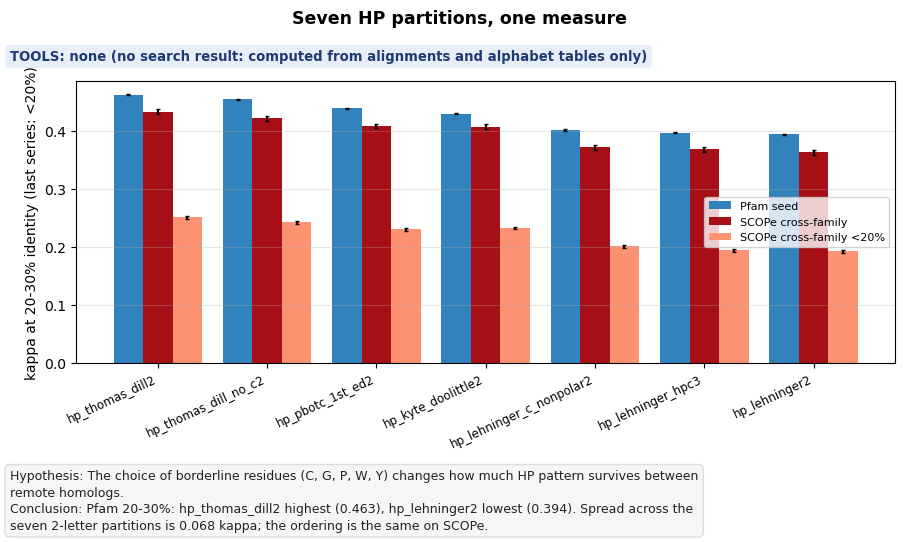

In [8]:
hp_set = hc.HP2 + ["hp_lehninger_hpc3"]
sf_hp = scope.filter(pl.col("category") == "same_superfamily_diff_family")
hp_p = hc.summarise(
    pfam.filter(
        pl.col("alphabet").is_in(hp_set) & (pl.col("identity_bin") == "20-30%")
    ),
    ["alphabet"],
    "kappa",
).with_columns(pl.lit("Pfam seed").alias("dataset"))
hp_s = hc.summarise(
    sf_hp.filter(
        pl.col("alphabet").is_in(hp_set) & (pl.col("identity_bin") == "20-30%")
    ),
    ["alphabet"],
    "kappa",
).with_columns(pl.lit("SCOPe cross-family").alias("dataset"))
hp_low = hc.summarise(
    sf_hp.filter(pl.col("alphabet").is_in(hp_set) & (pl.col("identity_bin") == "<20%")),
    ["alphabet"],
    "kappa",
).with_columns(pl.lit("SCOPe cross-family <20%").alias("dataset"))
hpk = pl.concat([hp_p, hp_s, hp_low], how="diagonal_relaxed")
order = hp_p.sort("kappa_mean", descending=True)["alphabet"].to_list()

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.27
for i, (ds, col) in enumerate(
    [
        ("Pfam seed", "#3182bd"),
        ("SCOPe cross-family", "#a50f15"),
        ("SCOPe cross-family <20%", "#fc9272"),
    ]
):
    s = (
        hpk.filter(pl.col("dataset") == ds)
        .with_columns(pl.col("alphabet").cast(pl.Enum(order)))
        .sort("alphabet")
    )
    ax.bar(
        np.arange(len(order)) + (i - 1) * w,
        s["kappa_mean"],
        w,
        yerr=[s["kappa_mean"] - s["kappa_lo"], s["kappa_hi"] - s["kappa_mean"]],
        color=col,
        label=ds,
        capsize=1.5,
    )
ax.set_xticks(np.arange(len(order)), order, rotation=25, ha="right", fontsize=8.5)
ax.set_ylabel("kappa at 20-30% identity (last series: <20%)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
print(
    hpk.select(
        "dataset",
        "alphabet",
        "n",
        pl.col("kappa_mean").round(3),
        pl.col("kappa_lo").round(3),
        pl.col("kappa_hi").round(3),
    ).sort("dataset", "kappa_mean", descending=[False, True])
)
top, bottom = order[0], order[-1]
hc.finish_figure(
    fig,
    FIG / "230_hp_variant_kappa.png",
    tools=hc.NO_TOOL,
    hypothesis="The choice of borderline residues (C, G, P, W, Y) changes how much HP pattern survives between remote homologs.",
    conclusion=(
        f"Pfam 20-30%: {top} highest ({hp_p.filter(pl.col('alphabet') == top)['kappa_mean'][0]:.3f}), {bottom} lowest ({hp_p.filter(pl.col('alphabet') == bottom)['kappa_mean'][0]:.3f}). "
        f"Spread across the seven 2-letter partitions is {hp_p.filter(pl.col('alphabet').is_in(hc.HP2))['kappa_mean'].max() - hp_p.filter(pl.col('alphabet').is_in(hc.HP2))['kappa_mean'].min():.3f} kappa; the ordering is the same on SCOPe."
    ),
    title="Seven HP partitions, one measure",
)

## 8. Conclusions

Written from the numbers above; see each figure's footer for the exact values.

1. The biology is real. Between homologs at 20-30% identity, the HP class of aligned
   residues agrees far above the composition null (kappa about 0.45 in both Pfam seed and
   SCOPe cross-family pairs), and about twice the chance-corrected agreement of the residues
   themselves. Below 20% identity, where sequence methods have nothing, HP kappa is still
   0.25-0.36 in homologs.
2. Part of it is packing rather than ancestry. Structurally aligned pairs from different
   folds show HP kappa around 0.1, so roughly a third of the cross-family signal under 20%
   identity would appear between any two well-superposed sequences. That fraction is a
   false-positive source for any HP-based search and a reason the null model has to be
   composition- and structure-aware, not just composition-aware.
3. An exact k-mer cannot use it. The longest exact HP run between 20-30% homologs is about
   12 residues on average (null 6), and only a few percent of pairs share a 23-mer. The
   sweep chose k=23-30 for the 2-letter arms because shorter k drowns in the null's own
   6-residue runs. That is the identity panel's zeros below 40%: not a refutation of the
   hypothesis, a ceiling on the primitive.
4. At matched bits per k-mer the 2-letter alphabets are the worst choice, not the best.
   At about 26 bits in the 20-30% bin, gbmr4 k=13 reaches 29% of pairs and sdm12 k=7
   reaches 26%, protein20 k=6 reaches 11%, and hp_thomas_dill2 k=26 reaches 2%. A long
   run in a 2-letter alphabet is broken by any one class flip along 26 positions, while a
   4- or 12-letter alphabet buys the same bits with a run a quarter or a fifth as long.
   Nominal bits also overstate what a 2-letter k-mer carries, since HP k-mers are far from
   uniformly distributed, so the effective-information comparison is harsher still. The
   "choose bits, not letters" framing survives; the "two letters suffice" framing does not.
5. The next experiment is the one that changes the primitive: a seed-and-extend that
   tolerates class flips in HP space (notebook 232), scored against the same identity bins.